<a href="https://colab.research.google.com/github/Reema-alghannam/Automatic-Fact-Checking-of-Arabic-Claims-/blob/main/NLP_Project_Over_Sampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




# **Introduction**
This project focuses on automated Arabic fact-checking using a comprehensive dataset of over 18,500 Arabic claims, labeled with categories such as True, False, Partly-False, Sarcasm, and Unverifiable. Our goal is to build models that can automatically classify these claims based on their factual accuracy.
To achieve this, we explore and compare three different approaches:


1.   BERT with Manual Preprocessing: We fine-tune the BERT model using Arabic text that we preprocess manually to handle challenges like diacritics and character encoding.
2.   BERT with CAMeL Tools Preprocessing: Here, we use CAMeL Tools, a set of Arabic NLP tools, to preprocess the text before feeding it into BERT. This automates tasks like normalization and tokenization, which could improve performance.
3. AraBERT with CAMeL Tools Preprocessing: AraBERT is a version of BERT specifically trained on Arabic text. We combine it with CAMeL Tools to see if a model designed for Arabic, paired with advanced preprocessing, performs better than standard BERT.

We also create an interactive interface using Gradio, allowing users to input Arabic claims and get real-time predictions on their accuracy. This makes the model easy to use and accessible.
By comparing these three methods, we aim to find the best approach for Arabic fact-checking while tackling challenges like Arabic’s complex grammar and character encoding.









In [ ]:
!pip install transformers datasets camel-tools scikit-learn matplotlib seaborn

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 556.4/556.4 kB 13.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.5/124.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
from camel_tools.utils.normalize import normalize_unicode, normalize_alef_maksura_ar, normalize_alef_ar, normalize_teh_marbuta_ar

# **Data Exploration**


In [ ]:
# Load the dataset
# This dataset appears to contain Arabic text labeled for classification tasks
data = pd.read_csv('/content/AraFacts 2.csv')
print(data.info())
print(data.head(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18598 entries, 0 to 18597
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ClaimID              18598 non-null  object
 1   claim                18598 non-null  object
 2   description          18131 non-null  object
 3   source               18598 non-null  object
 4   date                 18598 non-null  object
 5   source_label         18598 non-null  object
 6   normalized_label     18598 non-null  object
 7   source_category      13232 non-null  object
 8   normalized_category  18598 non-null  object
 9   source_url           18598 non-null  object
 10  claim_urls           18598 non-null  object
 11  evidence_urls        18598 non-null  object
 12  evidence_urls.1      16983 non-null  object
 13  claim_type           18598 non-null  int64 
dtypes: int64(1), object(13)
memory usage: 2.0+ MB
None
    ClaimID                                        

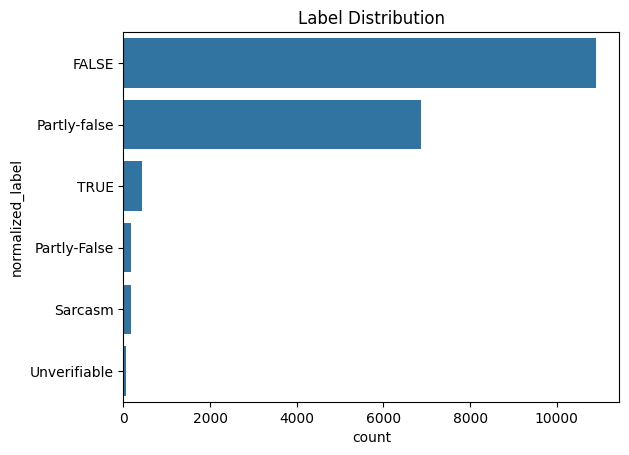

In [ ]:
# Visualize label distribution to understand class balance
sns.countplot(data['normalized_label'])
plt.title('Label Distribution')
plt.show()



1.   Imbalanced Dataset: The dataset is highly imbalanced, with some labels having significantly more samples than others.

2. Potential Impact on Model Performance: The imbalance could affect the model's ability to generalize across all labels, especially for the less frequent ones.

3.   Most columns are of type object (likely strings), except for claim_type, which is an integer.




## **Preprocessing**

In [ ]:
# Load dataset
df = pd.read_csv('/content/AraFacts 2.csv')

# Use 'normalized_label' as the label column
df['label'] = df['normalized_label']

# Define label mappings
text_label_mapping = {
    "TRUE": "True",
    "FALSE": "False",
    "Partly-False": "Partly-False",
    "Partly-false": "Partly-False",
    "Sarcasm": "Sarcasm",
    "Unverifiable": "Unverifiable"
}

label_to_id = {
    "True": 0,
    "False": 1,
    "Partly-False": 2,
    "Sarcasm": 3,
    "Unverifiable": 4
}

# Clean and standardize labels
def clean_labels(df):
    df['label'] = df['label'].str.strip().replace(text_label_mapping)
    df['label'] = df['label'].map(label_to_id)
    df = df[df['label'].notna()].astype({'label': 'int'})
    return df

# Apply cleaning
df = clean_labels(df)


In [ ]:
# Manual preprocessing
import re
from nltk.stem.isri import ISRIStemmer
from transformers import BertTokenizer, TFBertForSequenceClassification
from nltk.corpus import stopwords
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
arabic_stopwords = set(stopwords.words('arabic'))


stemmer = ISRIStemmer()

def manual_preprocess(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'[إأآا]', 'ا', text)  # Normalize alef
    text = re.sub(r'ة', 'ه', text)  # Convert 'ة' to 'ه'
    text = re.sub(r'ى', 'ي', text)  # Convert 'ى' to 'ي'
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = re.sub(r'\d+', '', text)  # Remove digits
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in arabic_stopwords]

    return " ".join(words)

# Camel Tools preprocessing
def camel_preprocess(text):
    text = normalize_unicode(text) # النص شكل واحد (مثل ازالة الحركات)
    text = normalize_alef_ar(text) # الالف شكل واحد
    text = normalize_alef_maksura_ar(text) #  الالف المقصورة
    text = normalize_teh_marbuta_ar(text) # التاء المربوطة
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in arabic_stopwords]
    return " ".join(words)



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Load tokenizers
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
arabert_tokenizer = AutoTokenizer.from_pretrained("aubmindlab/bert-base-arabertv02")

# Tokenization function
def tokenize_function(examples, tokenizer):
    return tokenizer(examples["clean_claim"], padding="max_length", truncation=True)

# Prepare datasets for each preprocessing method
def prepare_datasets(train_df, test_df, preprocess_fn, tokenizer):
    # Apply preprocessing
    train_df['clean_claim'] = train_df['claim'].apply(preprocess_fn)
    test_df['clean_claim'] = test_df['claim'].apply(preprocess_fn)

    train_dataset = Dataset.from_pandas(train_df)
    test_dataset = Dataset.from_pandas(test_df)

    # Tokenize
    tokenized_train = train_dataset.map(lambda x: tokenize_function(x, tokenizer), batched=True)
    tokenized_test = test_dataset.map(lambda x: tokenize_function(x, tokenizer), batched=True)

    return tokenized_train, tokenized_test

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/825k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.64M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

# **handling Imbalanc Dataset**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

def oversample_dataset(df, target_sizes):

    oversampled_dfs = []

    for label, target_size in target_sizes.items():
        # Get samples for the current class
        class_samples = df[df['label'] == label]

        # Oversample to the target size
        if len(class_samples) < target_size:
            oversampled_class = class_samples.sample(target_size, replace=True, random_state=42)
        else:
            oversampled_class = class_samples.sample(target_size, replace=False, random_state=42)

        oversampled_dfs.append(oversampled_class)

    # Include the remaining classes without oversampling
    remaining_classes = df[~df['label'].isin(target_sizes.keys())]
    oversampled_dfs.append(remaining_classes)

    # Combine all dataframes
    final_df = pd.concat(oversampled_dfs)

    # Shuffle the dataset to mix the samples well
    final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

    return final_df

    # Define target sizes for oversampling
target_sizes = {
    0: 5000,  # True
    3: 4500,  # Sarcasm
    4: 5000   # Unverifiable
}

# Apply oversampling
balanced_df = oversample_dataset(df, target_sizes)

# Split the dataset into training and testing sets
train_df, test_df = train_test_split(balanced_df, test_size=0.2, random_state=42)

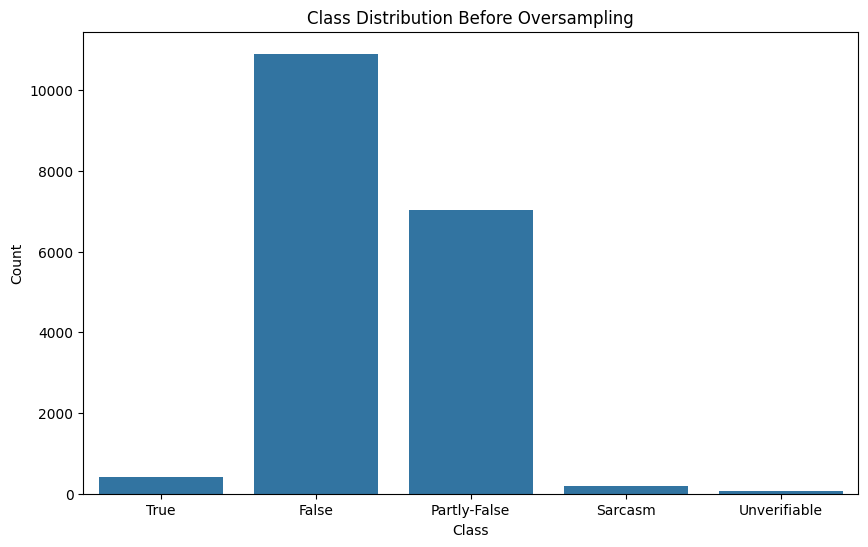

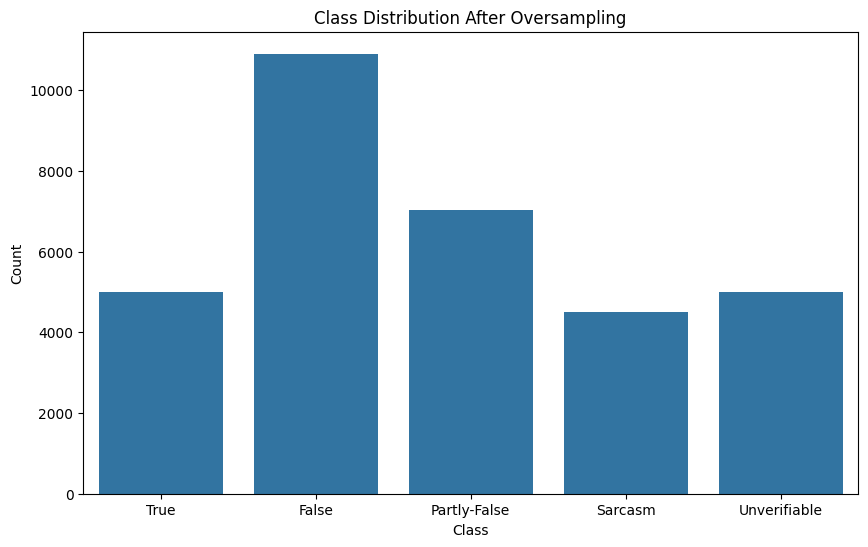

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Map label IDs to names for better visualization
id_to_label = {
    0: "True",
    1: "False",
    2: "Partly-False",
    3: "Sarcasm",
    4: "Unverifiable"
}
df['label_name'] = df['label'].map(id_to_label)

# Plot the original class distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='label_name', order=["True", "False", "Partly-False", "Sarcasm", "Unverifiable"])
plt.title('Class Distribution Before Oversampling')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


# Map label IDs to names for the oversampled dataset
balanced_df['label_name'] = balanced_df['label'].map(id_to_label)

# Plot the class distribution after oversampling
plt.figure(figsize=(10, 6))
sns.countplot(data=balanced_df, x='label_name', order=["True", "False", "Partly-False", "Sarcasm", "Unverifiable"])
plt.title('Class Distribution After Oversampling')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

To achive a balanced dataset we need to over sampling the minority classes, so we over sample True, Sarcasm, and Unverifiable. Ensuring that the model did not become biased toward the majority classes.

# **Model Implementation**

In [ ]:
def train_and_evaluate(model_name, tokenizer, train_dataset, test_dataset, save_dir):
    # Load model
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(label_to_id))

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"./results_{model_name}",
        evaluation_strategy="epoch",
        learning_rate=1e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=1,
        weight_decay=0.01,
        report_to="none",
    )

    # Metrics calculation
    def compute_metrics(p):
        preds = np.argmax(p.predictions, axis=1)
        return {
            'accuracy': accuracy_score(p.label_ids, preds),
            'f1': f1_score(p.label_ids, preds, average='weighted'),
            'precision': precision_score(p.label_ids, preds, average='weighted'),
            'recall': recall_score(p.label_ids, preds, average='weighted')
        }

    # Initialize Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics,
    )

    # Train model
    trainer.train()

    # Evaluate model
    results = trainer.evaluate()

    # Save the model and tokenizer
    model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)
    print(f"Model and tokenizer saved to {save_dir}")

    return model, results


**BERT maunal Preprocessing**  model training

In [ ]:
bert_manual_train, bert_manual_test = prepare_datasets(train_df, test_df, manual_preprocess, bert_tokenizer)
bert_manual_model = train_and_evaluate(
    "bert-base-multilingual-cased",
    bert_tokenizer,
    bert_manual_train,
    bert_manual_test,
    save_dir="/content/drive/MyDrive/NLP models OS/bert_manual"
)

Map:   0%|          | 0/25948 [00:00<?, ? examples/s]

Map:   0%|          | 0/6487 [00:00<?, ? examples/s]

A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Pl

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.594600,0.544540,0.796670,0.792778,0.792648,0.796670


Model and tokenizer saved to /content/drive/MyDrive/NLP models OS/bert_manual


 **BERT with Camel Preprocessing**  model training  

In [ ]:
bert_camel_train, bert_camel_test = prepare_datasets(train_df, test_df, camel_preprocess, bert_tokenizer)

bert_camel_model= train_and_evaluate(
    "bert-base-multilingual-cased",
    bert_tokenizer,
    bert_camel_train,
    bert_camel_test,
    save_dir="/content/drive/MyDrive/NLP models OS/bert_camel"
)

Map:   0%|          | 0/25948 [00:00<?, ? examples/s]

Map:   0%|          | 0/6487 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Pl

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.436100,0.408470,0.854786,0.852991,0.853042,0.854786


Model and tokenizer saved to /content/drive/MyDrive/NLP models OS/bert_camel


**AraBERT with Camel Preprocessing**  model training




In [ ]:
arabert_camel_train, arabert_camel_test = prepare_datasets(train_df, test_df, camel_preprocess, arabert_tokenizer)
arabert_camel_model = train_and_evaluate(
    "aubmindlab/bert-base-arabertv02",
    arabert_tokenizer,
    arabert_camel_train,
    arabert_camel_test,
    save_dir="/content/drive/MyDrive/NLP models OS/abert_camel"
)

Map:   0%|          | 0/25948 [00:00<?, ? examples/s]

Map:   0%|          | 0/6487 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.498200,0.451685,0.842300,0.841352,0.842360,0.842300


Model and tokenizer saved to /content/drive/MyDrive/NLP models OS/abert_camel


## **Evaluation and comparison**

In [ ]:
bert_manual_results, _ = bert_manual_model
bert_camel_results, _ = bert_camel_model
arabert_camel_results, _ = arabert_camel_model


Model Performance Comparison:
                           Model  Accuracy  F1-Score  Precision    Recall
0    BERT + Manual Preprocessing  0.796670  0.792778   0.792648  0.796670
1     BERT + Camel Preprocessing  0.854786  0.852991   0.853042  0.854786
2  AraBERT + Camel Preprocessing  0.842300  0.841352   0.842360  0.842300


<Figure size 1200x600 with 0 Axes>

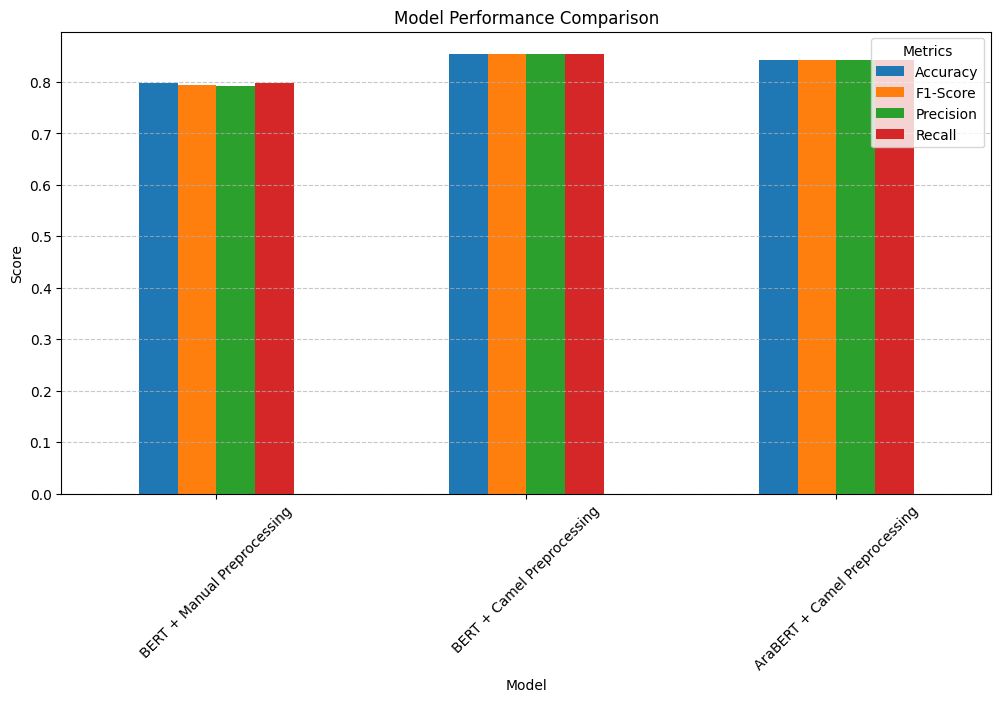

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

bert_manual_results = bert_manual_model[1]
bert_camel_results = bert_camel_model[1]
arabert_camel_results = arabert_camel_model[1]

# Create a comparison table
results_df = pd.DataFrame({
    'Model': ['BERT + Manual Preprocessing', 'BERT + Camel Preprocessing', 'AraBERT + Camel Preprocessing'],
    'Accuracy': [
        bert_manual_results['eval_accuracy'],
        bert_camel_results['eval_accuracy'],
        arabert_camel_results['eval_accuracy']
    ],
    'F1-Score': [
        bert_manual_results['eval_f1'],
        bert_camel_results['eval_f1'],
        arabert_camel_results['eval_f1']
    ],
    'Precision': [
        bert_manual_results['eval_precision'],
        bert_camel_results['eval_precision'],
        arabert_camel_results['eval_precision']
    ],
    'Recall': [
        bert_manual_results['eval_recall'],
        bert_camel_results['eval_recall'],
        arabert_camel_results['eval_recall']
    ]
})

# Display results
print("Model Performance Comparison:")
print(results_df)

# Visualization
plt.figure(figsize=(12, 6))
results_df.set_index('Model').plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(title="Metrics")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()




*  BERT + Manual Preprocessing has the lowest performance (Accuracy: 79.67%), indicating that manual text preprocessing is less effective.
*   AraBERT + Camel Preprocessing achieves(Accuracy: 84.23% ), showing that AraBERT benefits from Camel Tools preprocessing but slightly underperforms compared to the next model.

*  BERT + Camel Preprocessing performs best (Accuracy: 85.47%), suggesting that BERT combined with Camel Tools preprocessing enhances classification accuracy.






# **API Implemntation**

In [ ]:
!pip install gradio


import gradio as gr
import numpy as np
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from camel_tools.utils.normalize import normalize_unicode, normalize_alef_ar, normalize_alef_maksura_ar, normalize_teh_marbuta_ar

# Load the saved models and tokenizers
bert_manual_model = AutoModelForSequenceClassification.from_pretrained("/content/drive/MyDrive/NLP models OS/bert_manual")
bert_manual_tokenizer = AutoTokenizer.from_pretrained("/content/drive/MyDrive/NLP models OS/bert_manual")

bert_camel_model = AutoModelForSequenceClassification.from_pretrained("/content/drive/MyDrive/NLP models OS/bert_camel")
bert_camel_tokenizer = AutoTokenizer.from_pretrained("/content/drive/MyDrive/NLP models OS/bert_camel")

arabert_camel_model = AutoModelForSequenceClassification.from_pretrained("/content/drive/MyDrive/NLP models OS/abert_camel")
arabert_camel_tokenizer = AutoTokenizer.from_pretrained("/content/drive/MyDrive/NLP models OS/abert_camel")


id_to_label = {
    0 : "True",
    1 : "False",
    2 : "Partly-False",
    3 : "Sarcasm",
    4 : "Unverifiable"
}



# Define prediction function
def predict_claim(claim, model, tokenizer):

    # Preprocess the claim
    clean_claim = camel_preprocess(claim)

    # Tokenize the claim
    inputs = tokenizer(clean_claim, return_tensors="pt", padding=True, truncation=True)

    # Make a prediction
    outputs = model(**inputs)
    probs = outputs.logits.softmax(dim=1)
    pred_label = np.argmax(probs.detach().numpy())

    # Map the predicted label back to the original label
    predicted_label = id_to_label[pred_label]

    return predicted_label


def classify_claim(claim, model_choice):

    if model_choice == "BERT + Manual Preprocessing":
        return predict_claim(claim, bert_manual_model, bert_manual_tokenizer)
    elif model_choice == "BERT + Camel Preprocessing":
        return predict_claim(claim, bert_camel_model, bert_camel_tokenizer)
    elif model_choice == "AraBERT + Camel Preprocessing":
        return predict_claim(claim, arabert_camel_model, arabert_camel_tokenizer)
    else:
        return "Invalid model choice."

# Create the Gradio interface
model_choices = [
    "BERT + Manual Preprocessing",
    "BERT + Camel Preprocessing",
    "AraBERT + Camel Preprocessing"
]

interface = gr.Interface(
    fn=classify_claim,
    inputs=[
        gr.Textbox(label="تحقق من النص", placeholder="ادخل النص هنا..."),
        gr.Dropdown(label="النموذج", choices=model_choices)
    ],
    outputs=gr.Label(label="Predicted Label"),
    title="مرحباَ بك في مصنف الحقائق العربية",

)

interface.launch(share=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.9/321.9 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.8/94.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.5 MB/s eta 0:00:00
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://393128819da16fb950.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Conclusions**

A pre-trained converter (BERT) was used in this project to effectively create an Arabic text classification model. Normalization methods were used for preprocessing the dataset, and then named data was used to refine the model. The model works well, according to the evaluation criteria, which include accuracy, accuracy, recall and F1 grade. More information about erroneous classifications is provided via the Confusion Matrix view. With possible extensions of applications such as sentiment analysis and topic categorization, this method demonstrates the value of using deep learning models for natural Arabic language processing tasks.